In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import random_split, DataLoader, Dataset, ConcatDataset
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

# Calculo de similaridade
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
from scipy.spatial.distance import euclidean
from scipy.spatial.distance import cityblock
from sklearn.metrics import jaccard_score

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

# Define seed
SEED = 42

# Set the seed for reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # For multi-GPU setups
torch.backends.cudnn.deterministic = True  # Ensure deterministic behavior
torch.backends.cudnn.benchmark = False    # Disable if you want deterministic results

Feature_ambos = [
                #'L4_SRC_PORT',
                #'L4_DST_PORT',
                'PROTOCOL',
                #'L7_PROTO',
                'IN_BYTES',
                'IN_PKTS',
                'OUT_BYTES',
                'OUT_PKTS',
                #'TCP_FLAGS',
                #'CLIENT_TCP_FLAGS',
                #'SERVER_TCP_FLAGS',
                'FLOW_DURATION_MILLISECONDS',
                'DURATION_IN', 
                'DURATION_OUT',
                #'MIN_TTL', 
                #'MAX_TTL',
                'LONGEST_FLOW_PKT',
                #'SHORTEST_FLOW_PKT',
                #'MIN_IP_PKT_LEN', 
                'MAX_IP_PKT_LEN', 
                'SRC_TO_DST_SECOND_BYTES', 
                'DST_TO_SRC_SECOND_BYTES',
                'RETRANSMITTED_IN_BYTES', 
                'RETRANSMITTED_IN_PKTS', 
                'RETRANSMITTED_OUT_BYTES', 
                'RETRANSMITTED_OUT_PKTS',
                'SRC_TO_DST_AVG_THROUGHPUT', 
                'DST_TO_SRC_AVG_THROUGHPUT', 
                'NUM_PKTS_UP_TO_128_BYTES',
                'NUM_PKTS_128_TO_256_BYTES', 
                'NUM_PKTS_256_TO_512_BYTES', 
                'NUM_PKTS_512_TO_1024_BYTES',
                'NUM_PKTS_1024_TO_1514_BYTES', 
                #'TCP_WIN_MAX_IN', 
                #'TCP_WIN_MAX_OUT', 
                'ICMP_TYPE', 
                'ICMP_IPV4_TYPE',
                #'DNS_QUERY_ID', 
                'DNS_QUERY_TYPE', 
                #'DNS_TTL_ANSWER',
                #'FTP_COMMAND_RET_CODE',
                'Label', 
                'Attack']

Feature_name = [f for f in Feature_ambos if f not in ['Label', 'Attack']]

input_dim = 26

# Mapear todos os ataques
map_attacks = {'Benign':0, 
              'DoS':1,
              'dos':1,
              'Reconnaissance':2,
              'DDoS':3,
              'ddos':3,
              'Theft':4,
              'ransomware':5,
              'scanning':6,
              'xss':7,
              'mitm':8,
              'password':9,
              'Backdoor':10,
              'backdoor':10,
              'Analysis':11,
              'Generic':12,
              'Exploits':13,
              'Bot':14,
              'DoS_attacks-SlowHTTPTest':15,
              'SSH-Bruteforce':16,
              'DoS_attacks-Hulk':17,
              'Infilteration':18,
              'DDOS_attack-HOIC':19, 
              'FTP-BruteForce':20,
              'Brute_Force_-Web':21, 
              'DDoS_attacks-LOIC-HTTP':22, 
              'DoS_attacks-GoldenEye':23,
              'DDOS_attack-LOIC-UDP':24, 
              'DoS_attacks-Slowloris':25, 
              'Brute_Force_-XSS':26,
              'SQL_Injection':27
              }

In [2]:
class AE(nn.Module):
    def __init__(self, input_dim, latent_dim, dropout_rate):
        super(AE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.PReLU(),nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.PReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 128), 
            nn.PReLU(), nn.Dropout(dropout_rate),
            nn.Linear(128, 64), 
            nn.PReLU(), nn.Dropout(dropout_rate),
            nn.Linear(64, 32), 
            nn.PReLU(), nn.Dropout(dropout_rate),
            nn.Linear(32, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), 
            nn.PReLU(), nn.Dropout(dropout_rate),
            nn.Linear(32, 64), 
            nn.PReLU(), nn.Dropout(dropout_rate),
            nn.Linear(64, 128), 
            nn.PReLU(), nn.Dropout(dropout_rate),
            nn.Linear(128, 256), 
            nn.PReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 512), 
            nn.PReLU(), nn.Dropout(dropout_rate),
            nn.Linear(512, input_dim)
        )

    def forward(self, x):
        x_enc = self.encoder(x)
        recon = self.decoder(x_enc)
        return recon, x_enc

In [3]:
def ae_loss(recon_x, x):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    return recon_loss

In [4]:
class MLP(nn.Module):
    def __init__(self, latent_dim):
        super(MLP, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Dropout(0.3),

            nn.Linear(256, 64),
            nn.ReLU(True),
            nn.Dropout(0.2),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.mlp(x)

In [5]:
def get_datasets(dataset):
    
    if dataset == "dataset1":
         df = pd.read_csv('datasets/dataset1v2.csv') # NF-BoT-IoT-v2
    if dataset == "dataset2":
         df = pd.read_csv('datasets/dataset2v2.csv') # NF-ToN-IoT-v2
    if dataset == "dataset3":
         df = pd.read_csv('datasets/dataset3v2.csv') # NF-UNSW-NB15-v2
    if dataset == "dataset4":
         df = pd.read_csv('datasets/dataset4v2.csv') # NF-CICIDS2018-v3

    dataframe = df[Feature_ambos]
    
    return dataframe

In [6]:
def preprocessing_data(df):
    df_split = df.copy()
    df_split_label = df_split['Attack']
    df_split = df_split.drop('Attack',axis=1)
    df_split = df_split.drop('Label',axis=1)
    
    # Inicializando o MinMaxScaler (intervalo padrão é [0, 1])
    scaler = MinMaxScaler()

    # Ajustando e transformando os dados
    df_split = scaler.fit_transform(df_split)
    
    df_split_label = df_split_label.to_frame()
    x_split_train, x_split_temp, y_split_train, y_split_temp = train_test_split(df_split, df_split_label, test_size = 0.30, stratify=df_split_label)
    x_split_test, x_split_val, y_split_test, y_split_val = train_test_split(x_split_temp, y_split_temp, test_size = 0.50, stratify=y_split_temp)
    y_split_train['Attack'] = y_split_train['Attack'].apply(lambda x: 0 if x == 'Benign' else 1)
    z_split_test = y_split_test.copy()
    y_split_test['Attack'] = y_split_test['Attack'].apply(lambda x: 0 if x == 'Benign' else 1)
    #print(z_split_test)
    z_split_test['Attack']=z_split_test['Attack'].map(map_attacks)
    #z_test = torch.tensor(np.array(z_split_test, dtype=np.float32), dtype = torch.float)
    class_test = torch.tensor(np.array(y_split_test, dtype=np.float32), dtype = torch.float)
    class_attack = torch.tensor(np.array(z_split_test, dtype=np.float32), dtype = torch.float)
    dataset = torch.utils.data.TensorDataset(class_attack, class_test)
    z_test = torch.utils.data.DataLoader(dataset, batch_size=100)
    #print(z_split_test)
    y_split_val['Attack'] = y_split_val['Attack'].apply(lambda x: 0 if x == 'Benign' else 1)
    return x_split_train, y_split_train, x_split_val, y_split_val, x_split_test, y_split_test, z_test

In [7]:
def tensor_data(x_source1_train, y_source1_train):
    previsores_train = torch.tensor(np.array(x_source1_train), dtype = torch.float)
    class_train = torch.tensor(np.array(y_source1_train, dtype=np.float32), dtype = torch.float)
    dataset = torch.utils.data.TensorDataset(previsores_train, class_train)
    train_loader = torch.utils.data.DataLoader(dataset, batch_size=100, shuffle=True)
    return previsores_train, class_train, dataset, train_loader

In [8]:
def inicia_datasets(treino):
      df = get_datasets(treino)
      print(f"Prepara {treino}: {df.shape}")
      x_split_train, y_split_train, x_split_val, y_split_val, x_split_test, y_split_test, z_split_test = preprocessing_data(df)
      print( x_split_train.shape, y_split_train.shape)
      print( x_split_val.shape, y_split_val.shape)
      print( x_split_test.shape, y_split_test.shape)
      dataset_train, class_train, dataset_train, loader_train = tensor_data( x_split_train,  y_split_train)
      dataset_val, class_val, dataset_val, loader_val = tensor_data( x_split_val,  y_split_val)
      dataset_test, class_test, dataset_test, loader_test = tensor_data( x_split_test,  y_split_test)
      return dataset_train, class_train, dataset_train, loader_train, dataset_val, class_val, dataset_val, loader_val, dataset_test, class_test, dataset_test, loader_test, z_split_test

In [9]:
dataset = "dataset1" 
dataset_train1, class_train1, dataset_train1, loader_train1, dataset_val1, class_val1, dataset_val1, loader_val1, dataset_test1, class_test1, dataset_test1, loader_test1, z_split_test1 = inicia_datasets(dataset)
dataset = "dataset2" 
dataset_train2, class_train2, dataset_train2, loader_train2, dataset_val2, class_val2, dataset_val2, loader_val2, dataset_test2, class_test2, dataset_test2, loader_test2, z_split_test2 = inicia_datasets(dataset)
dataset = "dataset3" 
dataset_train3, class_train3, dataset_train3, loader_train3, dataset_val3, class_val3, dataset_val3, loader_val3, dataset_test3, class_test3, dataset_test3, loader_test3, z_split_test3 = inicia_datasets(dataset)
dataset = "dataset4" 
dataset_train4, class_train4, dataset_train4, loader_train4, dataset_val4, class_val4, dataset_val4, loader_val4, dataset_test4, class_test4, dataset_test4, loader_test4, z_split_test4 = inicia_datasets(dataset)

# Gerar ambos para teste e validação
test_dataset_combined = ConcatDataset([dataset_test1, dataset_test2, dataset_test3, dataset_test4])
test_loader_combined = DataLoader(test_dataset_combined, batch_size=loader_test1.batch_size, shuffle=True)
val_dataset_combined = ConcatDataset([dataset_val1, dataset_val2, dataset_val3, dataset_val4])
val_loader_combined = DataLoader(val_dataset_combined, batch_size=loader_val1.batch_size, shuffle=True)

Prepara dataset1: (224511, 28)
(157157, 26) (157157, 1)
(33677, 26) (33677, 1)
(33677, 26) (33677, 1)
Prepara dataset2: (224512, 28)
(157158, 26) (157158, 1)
(33677, 26) (33677, 1)
(33677, 26) (33677, 1)
Prepara dataset3: (142152, 28)
(99506, 26) (99506, 1)
(21323, 26) (21323, 1)
(21323, 26) (21323, 1)
Prepara dataset4: (223976, 28)
(156783, 26) (156783, 1)
(33597, 26) (33597, 1)
(33596, 26) (33596, 1)


In [10]:
def treina_modelo(modelo_AE1, modelo_AE2, modelo_AE3, modelo_MLP, input_dim, device):

    from sklearn.metrics import classification_report
    
    # Hiperparâmetros
    num_classes = 2
    epochs = 600
    lr = 0.001

    Alpha = 1.0
    Beta = 1.0
    Gama = 0.7
    
    patience = 50
    best_val_acc = 0
    epochs_no_improve = 0
    best_model_state = None
  
    # Otimizador conjunto
    params = list(modelo_MLP.parameters()) + list(modelo_AE1.parameters()) + list(modelo_AE2.parameters()) + list(modelo_AE3.parameters())    
    optimizer = torch.optim.Adam(params, lr=lr)

    # Scheduler: reduz o learning rate se a acurácia parar de melhorar
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=10, factor=0.5)

    # Funções de perda
    class_loss_fn = nn.BCEWithLogitsLoss()

    # Histórico
    loss_vals = []
    loss_valsAE = []
    loss_valsAE2 = []
    loss_valsAE3 = []
    loss_valsMLP = []
    val_simC = []
    val_distE = []
    val_distM = []
    val_accuracies = []
    val_losses = []
    
    dissim_cos = 0

    
    for epoch in range(epochs):
        
        modelo_AE1.train()
        modelo_AE2.train()
        modelo_AE3.train()
        modelo_MLP.train()
        
        sum_loss_recon = 0.0
        sum_loss_class = 0.0
        n_batches = 0
        epoch_loss_val = []
        epoch_simC = []
        epoch_corr = []
        epoch_distE = []
        epoch_distM = []
        epoch_simJ = []
        
        # Variaveis para similaridade
        simC = 0  # Cosseno 
        corr = 0  # Pearson 1.0 Correlação perfeita
        distE = 0  #  Eculidiana - Distância euclidiana
        distM = 0  # Distância de Manhattan
        simJ = 0  # Similaridade de Jaccard (para vetores binários ou conjuntos)

        for (X1, y1), (X2, y2), (X3, y3), (X4, y4) in zip(loader_train1, loader_train2, loader_train3, loader_train4):
    
            X = torch.cat([X1, X2, X3, X4], dim=0).to(device)
            y = torch.cat([y1, y2, y3, y4], dim=0).to(device).float()
            y = y.view(-1, 1)
            
            optimizer.zero_grad()
            
            # Forward do VAE1
            recon1, x_latent1 = modelo_AE1(X)
            
            # Forward do VAE2
            recon2, x_latent2 = modelo_AE2(X)

            # Forward do VAE3
            recon3, x_latent3 = modelo_AE3(X)

            # Perda de reconstrução (VAE1)
            recon_loss1 = ae_loss(recon1, X)
            
            # Perda de reconstrução (VAE2)
            recon_loss2 = ae_loss(recon2, X)

            # Perda de reconstrução (VAE3)
            recon_loss3 = ae_loss(recon3, X)

            # Classificação com vetor latente
            x_latent = torch.cat([x_latent1, x_latent2, x_latent3], dim=1)
            outputs = modelo_MLP(x_latent)
            loss_class = F.binary_cross_entropy(outputs, y)

            # Perda total
            loss_recon = (recon_loss1 + recon_loss2 + recon_loss3)/3

            # Diversidade entre representações (distância entre vetores latentes)
            #loss_diss = -(F.mse_loss(x_latent1, x_latent2) + F.mse_loss(x_latent1, x_latent3) + F.mse_loss(x_latent2, x_latent3))/3
            
            cos12 = 1 - F.cosine_similarity(x_latent1, x_latent2).mean()
            cos13 = 1 - F.cosine_similarity(x_latent1, x_latent3).mean()
            cos23 = 1 - F.cosine_similarity(x_latent2, x_latent3).mean()

            loss_diss = (cos12 + cos13 + cos23) / 3
            dissim_cos = loss_diss
            
            total_loss =  ( loss_recon * Alpha ) + ( loss_class * Beta ) + ( loss_diss * Gama )

            total_loss.backward()
            optimizer.step()

            sum_loss_recon += (recon_loss1.item() + recon_loss2.item() + recon_loss3.item()) / 3
            sum_loss_class += loss_class.item()
            n_batches += 1
            
            torch.cuda.empty_cache()
       
        # === Logs da época ===
        loss_epoch_recon = sum_loss_recon / n_batches
        loss_epoch_class = sum_loss_class / n_batches
        
        loss_valsAE.append(loss_epoch_recon)
        loss_valsMLP.append(loss_epoch_class)
        
        print(f"Epoch {epoch+1:02d}/{epochs} | Recon: {loss_epoch_recon:.4f} | Class: {loss_epoch_class:.4f} | Diss: {dissim_cos:.4f}")
        # Mostrar a simialridade da útlima instancia por época
        #print(f"Similaridade Média mu1, mu2 - Cosseno: {np.mean(simC)} | Euclidiana: {distE} | Manhattan: {distM}")
        modelo_AE1.eval()
        modelo_AE2.eval()
        modelo_AE3.eval()
        modelo_MLP.eval()
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            
           for (X1, y1), (X2, y2), (X3, y3), (X4, y4) in zip(loader_val1, loader_val2, loader_val3, loader_val4):
    
               X = torch.cat([X1, X2, X3, X4], dim=0).to(device)
               y = torch.cat([y1, y2, y3, y4], dim=0).to(device).float()
               y = y.view(-1, 1)
            
               optimizer.zero_grad()
            
               # Forward do VAE1, VAE2 e VAE3
               recon1, x_latent1 = modelo_AE1(X)
               recon2, x_latent2 = modelo_AE2(X)
               recon3, x_latent3 = modelo_AE3(X)
            
               # Classificação com vetor latente
               x_latent = torch.cat([x_latent1, x_latent2, x_latent3], dim=1)
               outputs = modelo_MLP(x_latent)
               loss_class = F.binary_cross_entropy(outputs, y)
               
               preds = (outputs > 0.5).float()

               # Calcula loss (BCE para binário)
               loss = F.binary_cross_entropy(outputs, y)
               
               epoch_loss_val.append(loss.item())
               
               all_preds.append(preds.cpu())
               all_labels.append(y.cpu())

        all_preds_list = torch.cat(all_preds)
        all_labels_list = torch.cat(all_labels)
        acc = (all_preds_list.view(-1) == all_labels_list.view(-1)).float().mean().item()
        loss_val = sum(epoch_loss_val) / len(epoch_loss_val)
    
        val_accuracies.append(acc)
        val_losses.append(loss_val)
        print(f"Acurácia: {acc}")

        # Atualiza scheduler com base na acurácia de validação
        scheduler.step(acc)

        # Mostra o learning rate atual
        for param_group in optimizer.param_groups:
            current_lr = param_group['lr']
        print(f"Learning Rate atual: {current_lr:.6f}")        

        # Early stopping
        if acc > best_val_acc:
            best_val_acc = acc
            epochs_no_improve = 0
            best_model_state = modelo_MLP.state_dict()
        else:
            epochs_no_improve += 1
            print(f"Sem melhoria na validação por {epochs_no_improve} época(s).")
            if epochs_no_improve >= patience:
                print(f"Early stopping ativado na época {epoch+1}")
                break

    # Restaurar melhor modelo
    if best_model_state is not None:
        modelo_MLP.load_state_dict(best_model_state)
        print("Melhor modelo MLP restaurado com base na menor perda de validação.")  
    
    return  all_preds, all_labels

In [11]:
# Instanciando o modelo
input_dim = 26
latent_dim = 16
modelo_AE1 = AE(input_dim,latent_dim,0.1)
modelo_AE2 = AE(input_dim,latent_dim,0.2)
modelo_AE3 = AE(input_dim,latent_dim,0.3)
latent_dim = 48
modelo_MLP = MLP(latent_dim)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [12]:
import time 

start = time.time()
train_preds, train_labels = treina_modelo(modelo_AE1, modelo_AE2, modelo_AE3, modelo_MLP, input_dim, device)
end = time.time()
tempo = end - start
print("Tempo de execução: ", tempo)

import psutil
import os

process = psutil.Process(os.getpid())
print("Memória usada (MB):", process.memory_info().rss / 1024**2)

Epoch 01/600 | Recon: 32.9447 | Class: 0.6046 | Diss: 0.2180
Acurácia: 0.6773031949996948
Learning Rate atual: 0.001000
Epoch 02/600 | Recon: 10.4928 | Class: 0.5650 | Diss: 0.1402
Acurácia: 0.6778761148452759
Learning Rate atual: 0.001000
Epoch 03/600 | Recon: 8.3040 | Class: 0.5508 | Diss: 0.1228
Acurácia: 0.6797353029251099
Learning Rate atual: 0.001000
Epoch 04/600 | Recon: 7.2992 | Class: 0.5426 | Diss: 0.1086
Acurácia: 0.6766366958618164
Learning Rate atual: 0.001000
Sem melhoria na validação por 1 época(s).
Epoch 05/600 | Recon: 6.7361 | Class: 0.5352 | Diss: 0.0943
Acurácia: 0.7296867370605469
Learning Rate atual: 0.001000
Epoch 06/600 | Recon: 6.3904 | Class: 0.5277 | Diss: 0.0847
Acurácia: 0.7288097739219666
Learning Rate atual: 0.001000
Sem melhoria na validação por 1 época(s).
Epoch 07/600 | Recon: 6.1153 | Class: 0.5064 | Diss: 0.0864
Acurácia: 0.7553055882453918
Learning Rate atual: 0.001000
Epoch 08/600 | Recon: 5.9576 | Class: 0.4799 | Diss: 0.0863
Acurácia: 0.773043513

Epoch 59/600 | Recon: 5.5809 | Class: 0.2923 | Diss: 0.0976
Acurácia: 0.8904271125793457
Learning Rate atual: 0.001000
Sem melhoria na validação por 1 época(s).
Epoch 60/600 | Recon: 4.9654 | Class: 0.2945 | Diss: 0.0821
Acurácia: 0.8891292214393616
Learning Rate atual: 0.001000
Sem melhoria na validação por 2 época(s).
Epoch 61/600 | Recon: 4.7696 | Class: 0.2906 | Diss: 0.0874
Acurácia: 0.8900061845779419
Learning Rate atual: 0.001000
Sem melhoria na validação por 3 época(s).
Epoch 62/600 | Recon: 4.4780 | Class: 0.2883 | Diss: 0.0777
Acurácia: 0.891315758228302
Learning Rate atual: 0.001000
Sem melhoria na validação por 4 época(s).
Epoch 63/600 | Recon: 4.4981 | Class: 0.2878 | Diss: 0.0864
Acurácia: 0.877354621887207
Learning Rate atual: 0.001000
Sem melhoria na validação por 5 época(s).
Epoch 64/600 | Recon: 4.4073 | Class: 0.2864 | Diss: 0.0730
Acurácia: 0.8969283103942871
Learning Rate atual: 0.001000
Epoch 65/600 | Recon: 4.6171 | Class: 0.2872 | Diss: 0.0810
Acurácia: 0.890661

Epoch 115/600 | Recon: 2.9911 | Class: 0.2161 | Diss: 0.0602
Acurácia: 0.940086305141449
Learning Rate atual: 0.000250
Epoch 116/600 | Recon: 3.0213 | Class: 0.2186 | Diss: 0.0547
Acurácia: 0.940074622631073
Learning Rate atual: 0.000250
Sem melhoria na validação por 1 época(s).
Epoch 117/600 | Recon: 3.0300 | Class: 0.2219 | Diss: 0.0637
Acurácia: 0.9384258985519409
Learning Rate atual: 0.000250
Sem melhoria na validação por 2 época(s).
Epoch 118/600 | Recon: 2.9712 | Class: 0.2218 | Diss: 0.0582
Acurácia: 0.9181389808654785
Learning Rate atual: 0.000250
Sem melhoria na validação por 3 época(s).
Epoch 119/600 | Recon: 2.9803 | Class: 0.2183 | Diss: 0.0543
Acurácia: 0.9202203154563904
Learning Rate atual: 0.000250
Sem melhoria na validação por 4 época(s).
Epoch 120/600 | Recon: 3.0720 | Class: 0.2185 | Diss: 0.0517
Acurácia: 0.9403084516525269
Learning Rate atual: 0.000250
Epoch 121/600 | Recon: 2.9468 | Class: 0.2166 | Diss: 0.0479
Acurácia: 0.9462600946426392
Learning Rate atual: 0.0

Acurácia: 0.9485167860984802
Learning Rate atual: 0.000031
Sem melhoria na validação por 1 época(s).
Epoch 169/600 | Recon: 2.6164 | Class: 0.1885 | Diss: 0.0394
Acurácia: 0.9495691061019897
Learning Rate atual: 0.000031
Sem melhoria na validação por 2 época(s).
Epoch 170/600 | Recon: 2.6559 | Class: 0.1891 | Diss: 0.0424
Acurácia: 0.9487740397453308
Learning Rate atual: 0.000031
Sem melhoria na validação por 3 época(s).
Epoch 171/600 | Recon: 2.6366 | Class: 0.1875 | Diss: 0.0470
Acurácia: 0.9490897059440613
Learning Rate atual: 0.000031
Sem melhoria na validação por 4 época(s).
Epoch 172/600 | Recon: 2.6539 | Class: 0.1893 | Diss: 0.0499
Acurácia: 0.9490429759025574
Learning Rate atual: 0.000031
Sem melhoria na validação por 5 época(s).
Epoch 173/600 | Recon: 2.6474 | Class: 0.1879 | Diss: 0.0454
Acurácia: 0.9487155675888062
Learning Rate atual: 0.000031
Sem melhoria na validação por 6 época(s).
Epoch 174/600 | Recon: 2.6472 | Class: 0.1871 | Diss: 0.0485
Acurácia: 0.9493703246116638

Epoch 220/600 | Recon: 2.6014 | Class: 0.1826 | Diss: 0.0428
Acurácia: 0.9490780234336853
Learning Rate atual: 0.000004
Sem melhoria na validação por 18 época(s).
Epoch 221/600 | Recon: 2.5874 | Class: 0.1818 | Diss: 0.0488
Acurácia: 0.9495223760604858
Learning Rate atual: 0.000004
Sem melhoria na validação por 19 época(s).
Epoch 222/600 | Recon: 2.5793 | Class: 0.1818 | Diss: 0.0431
Acurácia: 0.949697732925415
Learning Rate atual: 0.000004
Sem melhoria na validação por 20 época(s).
Epoch 223/600 | Recon: 2.6387 | Class: 0.1826 | Diss: 0.0432
Acurácia: 0.948972761631012
Learning Rate atual: 0.000004
Sem melhoria na validação por 21 época(s).
Epoch 224/600 | Recon: 2.5830 | Class: 0.1827 | Diss: 0.0396
Acurácia: 0.9496042132377625
Learning Rate atual: 0.000002
Sem melhoria na validação por 22 época(s).
Epoch 225/600 | Recon: 2.5890 | Class: 0.1832 | Diss: 0.0408
Acurácia: 0.9497678875923157
Learning Rate atual: 0.000002
Sem melhoria na validação por 23 época(s).
Epoch 226/600 | Recon: 2

Epoch 271/600 | Recon: 2.5822 | Class: 0.1833 | Diss: 0.0460
Acurácia: 0.9502005577087402
Learning Rate atual: 0.000000
Sem melhoria na validação por 22 época(s).
Epoch 272/600 | Recon: 2.5825 | Class: 0.1829 | Diss: 0.0391
Acurácia: 0.9506098031997681
Learning Rate atual: 0.000000
Sem melhoria na validação por 23 época(s).
Epoch 273/600 | Recon: 2.5747 | Class: 0.1814 | Diss: 0.0431
Acurácia: 0.9495223760604858
Learning Rate atual: 0.000000
Sem melhoria na validação por 24 época(s).
Epoch 274/600 | Recon: 2.5870 | Class: 0.1819 | Diss: 0.0440
Acurácia: 0.9502823948860168
Learning Rate atual: 0.000000
Sem melhoria na validação por 25 época(s).
Epoch 275/600 | Recon: 2.5868 | Class: 0.1808 | Diss: 0.0405
Acurácia: 0.9500485062599182
Learning Rate atual: 0.000000
Sem melhoria na validação por 26 época(s).
Epoch 276/600 | Recon: 2.5758 | Class: 0.1815 | Diss: 0.0378
Acurácia: 0.9486570954322815
Learning Rate atual: 0.000000
Sem melhoria na validação por 27 época(s).
Epoch 277/600 | Recon:

In [13]:
def testa(target_test, treino, labels_test):
  # Valida source
  modelo_AE1.eval()
  modelo_AE2.eval()
  modelo_AE3.eval()
  modelo_MLP.eval()
  all_preds, all_labels, all_attacks = [], [], []

  with torch.no_grad():
      
    for (X, y), (z, y2) in zip(target_test, labels_test):

         X = X.to(device)
         y = y.to(device).float()
         y = y.view(-1, 1)
         z = z.to(device).float()
         z = z.view(-1, 1)
            
         # Forward do VAE1, VAE2
         recon1, x_latent1 = modelo_AE1(X)
         recon2, x_latent2 = modelo_AE2(X)
         recon3, x_latent3 = modelo_AE3(X)
            
         # Classificação com vetor latente
         x_latent = torch.cat([x_latent1, x_latent2, x_latent3], dim=1)
         outputs = modelo_MLP(x_latent)
         loss_class = F.binary_cross_entropy(outputs, y)
               
         preds = (outputs > 0.5).float()

         # Calcula loss (BCE para binário)
         loss = F.binary_cross_entropy(outputs, y)
               
         all_preds.append(preds.cpu())
         all_labels.append(y.cpu())
         all_attacks.append(z.cpu())
        
  all_preds_list = torch.cat(all_preds)
  all_labels_list = torch.cat(all_labels)
  all_attacks_list = torch.cat(all_attacks)

  acc = (all_preds_list.view(-1) == all_labels_list.view(-1)).float().mean().item()

  # Matriz de confusão
  matriz2 = confusion_matrix(all_preds_list.numpy().round(), all_labels_list.numpy().round())
  sns.set(rc={"figure.figsize": (6, 6)})
  title = "Matriz de Confusão: " + treino
  sns.heatmap(matriz2/np.sum(matriz2), annot=True, annot_kws={'size': 10}, fmt='.2%', cmap='Blues').set_title(title)
  plt.show()

  # Extração dos elementos da matriz (para problema binário)
  TN, FP, FN, TP = matriz2.ravel()

  # Cálculo das métricas
  TPR = TP / (TP + FN) if (TP + FN) != 0 else 0  # Sensibilidade, Recall
  TNR = TN / (TN + FP) if (TN + FP) != 0 else 0  # Especificidade
  F1 = f1_score(all_labels_list.detach().numpy().round(), all_preds_list.detach().numpy().round())
  return TPR, TNR, F1, acc, all_preds_list.view(-1), all_labels_list.view(-1), all_attacks_list.view(-1)

Treinando com Ambos e validando com dataset1


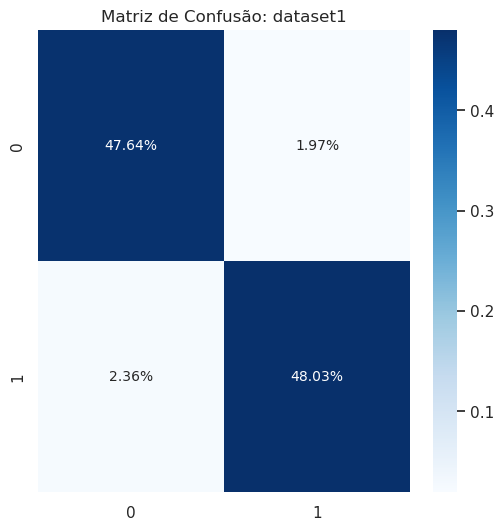

Treinando com Ambos e validando com dataset2


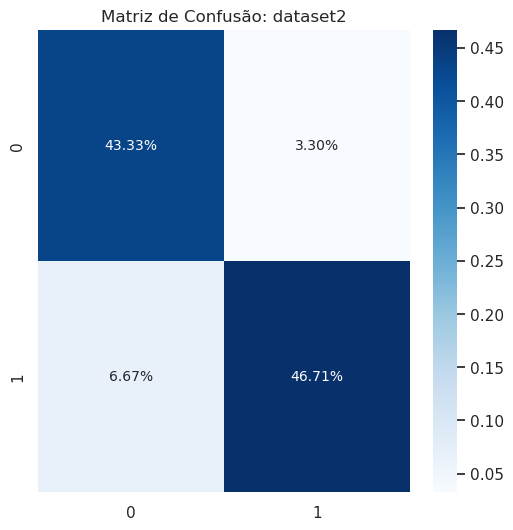

Treinando com Ambos e validando com dataset3


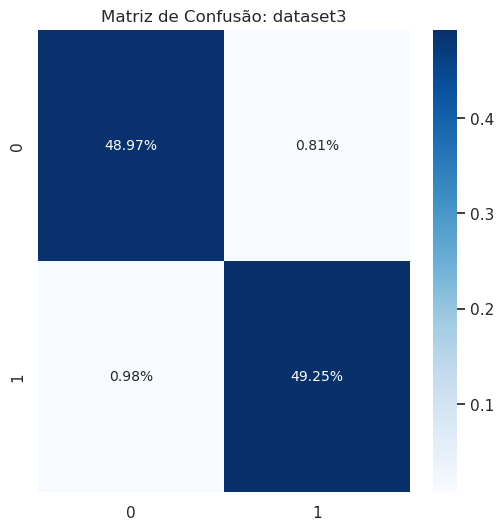

Treinando com Ambos e validando com dataset4


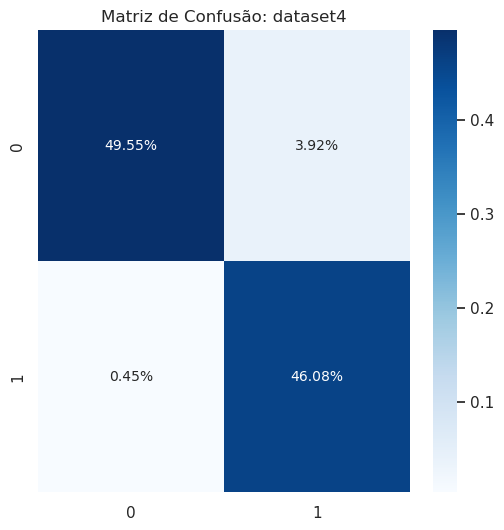

----------------------------------------------
Resumo da validação nos Datasets:
    Dataset       TPR       TNR  F1-Score  Acurácia
0  dataset1  0.953155  0.960374  0.956905  0.956736
1  dataset2  0.875049  0.929308  0.903602  0.900347
2  dataset3  0.980577  0.983795  0.982228  0.982179
3  dataset4  0.990340  0.926687  0.954733  0.956304
----------------------------------------------


In [14]:
datasets = ["dataset1", "dataset2", "dataset3", "dataset4"]
target_test = [loader_test1, loader_test2, loader_test3, loader_test4]
labels_test = [z_split_test1, z_split_test2, z_split_test3, z_split_test4]

TPRs = []
TNRs = []
F1s = []
ACCs = []
all_preds_lists = []
all_labels_lists = []
all_attacks_lists = []

for data, teste, labels  in zip(datasets, target_test, labels_test):
    print(f"Treinando com Ambos e validando com {data}")
    TPR, TNR, F1, acc, all_preds_list, all_labels_list, all_attacks_list = testa(teste, data, labels)
    TPRs.append(TPR)
    TNRs.append(TNR)
    F1s.append(F1)
    ACCs.append(acc)
    all_preds_lists.extend(all_preds_list)
    all_labels_lists.extend(all_labels_list)
    all_attacks_lists.extend(all_attacks_list)
    
# Criação da tabela
df = pd.DataFrame({
    'Dataset': datasets,
    'TPR': TPRs,
    'TNR': TNRs,
    'F1-Score': F1s,
    'Acurácia': ACCs
})
print("----------------------------------------------")
print("Resumo da validação nos Datasets:")
print(df)
print("----------------------------------------------")

In [15]:
# Combinar todas as predições em um dataframe para tabulação

all_labels = [t.item() for t in all_labels_lists]
all_preds = [t.item() for t in all_preds_lists]
all_attacks = [t.item() for t in all_attacks_lists]

# Inverter dicionario
map_attacks_inv = {v: k for k, v in map_attacks.items()}

df = pd.DataFrame({
    "Real": all_labels,
    "Previsto": all_preds,
    "Ataque": all_attacks
})

# Criar coluna de acerto/erro
df["Acertou"] = df["Real"] == df["Previsto"]

# Agrupar predições por tipo de ataque
tabela = df.groupby("Ataque").agg(
    Total=("Real","count"),
    Acertos=("Acertou","sum")
)

# Adicionar Acurácia por ataque
tabela["Acurácia"] = tabela["Acertos"] / tabela["Total"]

# Adicionar F1 por ataque
f1_por_ataque = {}
TP_por_ataque = {}
TN_por_ataque = {}
FP_por_ataque = {}
FN_por_ataque = {}
for atk, grupo in df.groupby("Ataque"):
    f1_por_ataque[atk] = f1_score(grupo["Real"], grupo["Previsto"], zero_division=0)
    TP_por_ataque[atk] = ((grupo["Real"] == 1) & (grupo["Previsto"] == 1)).sum()
    TN_por_ataque[atk] = ((grupo["Real"] == 0) & (grupo["Previsto"] == 0)).sum()
    FP_por_ataque[atk] = ((grupo["Real"] == 0) & (grupo["Previsto"] == 1)).sum()
    FN_por_ataque[atk] = ((grupo["Real"] == 1) & (grupo["Previsto"] == 0)).sum()

tabela["TP"] = tabela.index.map(TP_por_ataque)
tabela["TN"] = tabela.index.map(TN_por_ataque)
tabela["FP"] = tabela.index.map(FP_por_ataque)
tabela["FN"] = tabela.index.map(FN_por_ataque)
tabela["F1"] = tabela.index.map(f1_por_ataque)


# Renomear indice pelo nome do ataque
tabela.index = tabela.index.map(map_attacks_inv)

print("Resumo por tipo de ataque:")
print(tabela)

Resumo por tipo de ataque:
                          Total  Acertos  Acurácia     TP     TN    FP    FN  \
Ataque                                                                         
Benign                    61125    57810  0.945767  28873  28937  1716  1599   
dos                        8527     8061  0.945350   4054   4007   268   198   
Reconnaissance             7409     7116  0.960454   3580   3536   165   128   
ddos                       9825     9120  0.928244   4702   4418   460   245   
Theft                       364      349  0.958791    174    175     7     8   
ransomware                  514      470  0.914397    245    225    26    18   
scanning                   2166     1946  0.898430   1037    909   141    79   
xss                        2167     1965  0.906784   1040    925   127    75   
mitm                       1158     1036  0.894646    518    518    80    42   
password                   2167     1960  0.904476   1013    947   137    70   
backdoor     